In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [7]:
NUM_POLICY = 3

# Load flat/rough/cut weight dataset
# terrain = {"flat" :[], "rough":[] , "weight":[]}
# for i in terrain.keys(): # each run have 3 policies
#     for policy in range(NUM_POLICY):
#         terrain[i].append(np.load(f"../data/eval/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
# for key, value in terrain.items():
#     terrain[key] = np.array(value)

# # Load sensory albation dataset
# sensor_loss = {"full":[] , "no_pos":[] , "no_vel":[], "no_action":[], "no_IMU":[] , "no_fc":[]}
# for i,keys in enumerate(sensor_loss.keys()):
#     for policy in range(NUM_POLICY):    
#         sensor_loss[keys].append(np.load(f"../data/eval/new_pol2/case_{i}-policy_{policy}.npy" , allow_pickle=True).item())
# for key, value in sensor_loss.items():
#     sensor_loss[key] = np.array(value)

motor_dataset = {f"motor{i}" :[] for i in range(5)}
for i in motor_dataset.keys(): # each run have 3 policies
    for policy in range(NUM_POLICY):
        motor_dataset[i].append(np.load(f"../data/eval/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
for key, value in motor_dataset.items():
    motor_dataset[key] = np.array(value)


# [case:str][number_file:int][data/brain:str]

In [8]:
selected_dataset = motor_dataset

In [9]:

performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(3)}
max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(3)}
avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(3)}

for policy in range(NUM_POLICY):
    for case in selected_dataset.keys():
        reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
        performance[f"policy{policy}"][case] = reward

        max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
        max_distance[f"policy{policy}"][case] = max_pos_x

        vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
        avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)

print(performance.keys())  # Prints the policy keys
print(performance["policy0"].keys())  # Prints the case keys under "policy0"
print(max_distance.keys())  # Prints the policy keys
print(max_distance["policy0"].keys())  # Prints the case keys under "policy0"
# [num_policy][data group][data inside]


dict_keys(['policy0', 'policy1', 'policy2'])
dict_keys(['motor0', 'motor1', 'motor2', 'motor3', 'motor4'])
dict_keys(['policy0', 'policy1', 'policy2'])
dict_keys(['motor0', 'motor1', 'motor2', 'motor3', 'motor4'])


In [10]:
def plot_performance(performance , title:str="Performance"):
    num_col = len(performance.keys())  # Number of policies (columns)
    num_group = len(performance['policy0'].keys())  # Number of cases (groups)
    fig, axes = plt.subplots(1, num_col, figsize=(12, 6))
    
    pastel_colors = sns.color_palette("pastel", n_colors=num_group)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(list(performance['policy0'].keys()))}
    
    for i, policy in enumerate(performance.keys()):
        ax = axes[i]  # Get the axis for this policy subplot
        box = ax.boxplot(
            [performance[policy][case] for case in performance[policy].keys()],  # List of data for each case
                vert=True, patch_artist=True,zorder=1  # fill with color  # Set the tick labels to be the case names
        )
        ax.set_xticklabels(list(performance[policy].keys()), fontsize=8) 
        for j, patch in enumerate(box['boxes']):
            case = list(performance[policy].keys())[j]  # Get the case corresponding to the current box
            patch.set_facecolor(case_colors[case])  # Set the color for the box based on the case

        for j, case in enumerate(performance[policy].keys()):
            x_vals = [j + 1 + np.random.normal(0, 0.1) for _ in performance[policy][case]]  # Jitter with normal noise
            ax.scatter(x_vals, performance[policy][case], alpha=0.8, s=5, label=case, zorder=2)
        ax.set_title(f"{title} for {policy}")
    plt.tight_layout()
    plt.show()

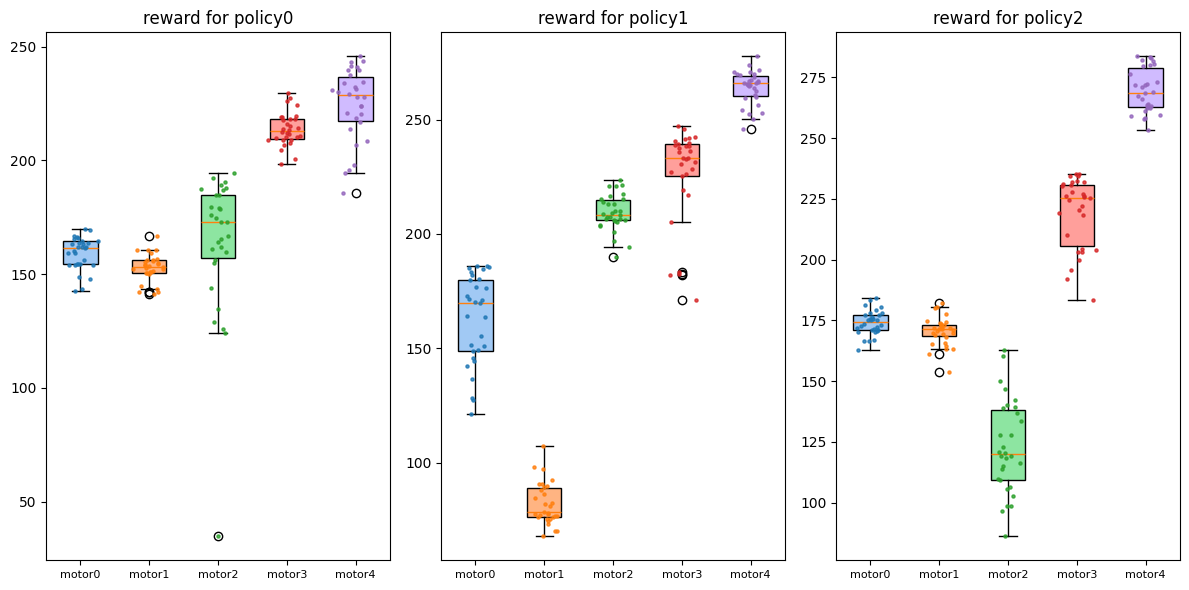

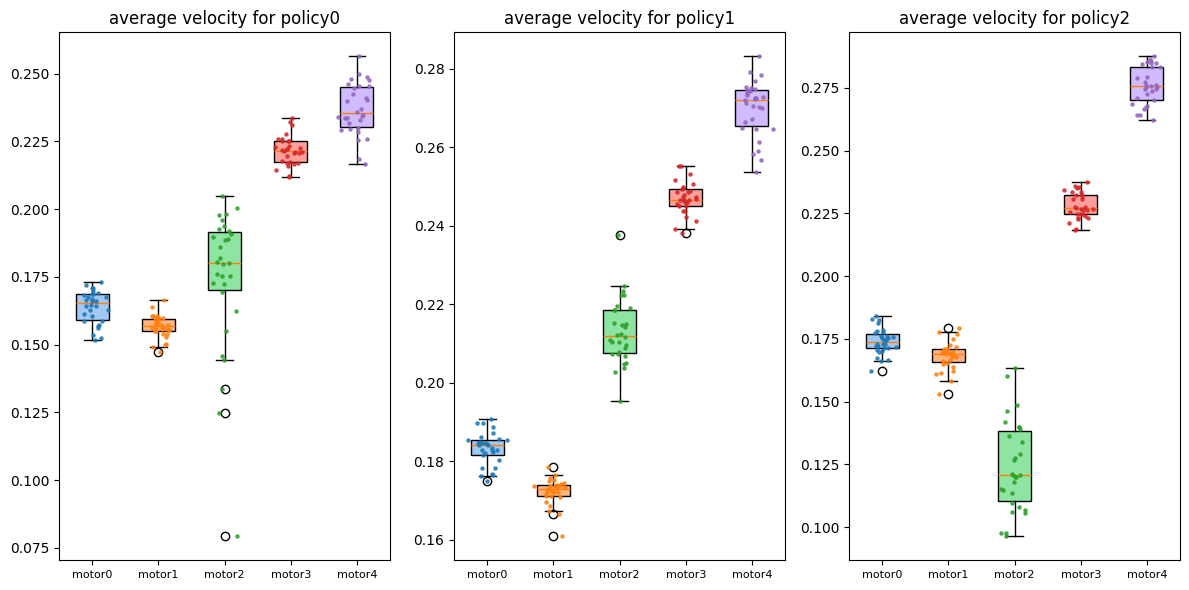

: 

In [ ]:
plot_performance(performance, title="reward")
plot_performance(avg_vel , title="average velocity")